# Jaccpot GPU Runtime Benchmark (Radix Tree)

This notebook benchmarks Jaccpot runtime on GPU using yggdrax radix-tree settings tuned for throughput.

Included plots:
- `Runtime scaling with particle count (full vs prepared split)`
- `prepare_state component breakdown`

In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "0"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

# Index precision switch (must be set before importing JAX/jaccpot/yggdrax).
INDEX_PRECISION = "int32"  # choose from: "int32", "int64"
os.environ.setdefault("JACCPOT_INDEX_PRECISION", INDEX_PRECISION)
os.environ.setdefault("YGGDRAX_INDEX_PRECISION", INDEX_PRECISION)
print("Index precision:", os.environ.get("JACCPOT_INDEX_PRECISION"))

# GPU memory-fragmentation / graph-memory safeguards.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

# Runtime cache limits (reduce transient cache memory pressure for capacity runs).
os.environ.setdefault("JACCPOT_OPERATOR_CACHE_MAX", "256")
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_MAX", "16")
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_MAX", "16")
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_ENTRY_MAX_BYTES", str(16 * 1024 * 1024))
os.environ.setdefault("JACCPOT_GROUPED_OPERATOR_CACHE_TOTAL_MAX_BYTES", str(64 * 1024 * 1024))
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_ENTRY_MAX_BYTES", str(8 * 1024 * 1024))
os.environ.setdefault("JACCPOT_GROUPED_SEGMENT_CACHE_TOTAL_MAX_BYTES", str(32 * 1024 * 1024))
print(
    "Runtime cache limits:",
    {
        "op_max": os.environ.get("JACCPOT_OPERATOR_CACHE_MAX"),
        "grp_op_max": os.environ.get("JACCPOT_GROUPED_OPERATOR_CACHE_MAX"),
        "grp_seg_max": os.environ.get("JACCPOT_GROUPED_SEGMENT_CACHE_MAX"),
        "grp_op_total_mb": int(os.environ.get("JACCPOT_GROUPED_OPERATOR_CACHE_TOTAL_MAX_BYTES", "0")) // (1024 * 1024),
        "grp_seg_total_mb": int(os.environ.get("JACCPOT_GROUPED_SEGMENT_CACHE_TOTAL_MAX_BYTES", "0")) // (1024 * 1024),
    },
)



Set CUDA_VISIBLE_DEVICES = 0
Index precision: int32


In [2]:
import json
from dataclasses import replace
import pathlib
import subprocess
import sys
import inspect
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax import Tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors

from examples import benchmark_utils as bench_utils

In [3]:
# GPU sanity check
all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError(
        "No GPU device visible to JAX. Ensure CUDA/ROCm is configured before running this notebook."
    )
print("Using GPU:", gpu_devices[0])

JAX backend: gpu
Visible devices: [CudaDevice(id=0)]
Using GPU: cuda:0


## Benchmark Configuration

In [4]:
# Particle-count sweep for scaling plots (includes your target N=131072)
runtime_particle_counts = [8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216]
runtime_leaf_size = 64
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1
runtime_isolate_process_per_n = True
runtime_autotune_cache_path = REPO_ROOT / "benchmarks" / "m2l_autotune_cache.json"
runtime_traversal_autotune_cache_path = REPO_ROOT / "benchmarks" / "traversal_autotune_cache.json"
runtime_enable_traversal_autotune = True
runtime_traversal_autotune_probe_n = 131072
runtime_traversal_candidates = [
    dict(max_pair_queue=131072, process_block=128, max_interactions_per_node=1024, max_neighbors_per_leaf=256),
    dict(max_pair_queue=131072, process_block=256, max_interactions_per_node=2048, max_neighbors_per_leaf=512),
    dict(max_pair_queue=262144, process_block=256, max_interactions_per_node=4096, max_neighbors_per_leaf=1024),
    dict(max_pair_queue=524288, process_block=512, max_interactions_per_node=4096, max_neighbors_per_leaf=1024),
]


runtime_benchmark_scope = "steady_eval"
runtime_worker_autotune_traversal = True
runtime_worker_autotune_nearfield_chunk = True
runtime_nearfield_chunk_candidates = [64, 128, 256, 512]
runtime_runtime_autotune_cache_path = REPO_ROOT / "benchmarks" / "runtime_worker_autotune_cache.json"


# Memory-first large-N overrides (kept strict to maximize fit at high N).
runtime_memory_first_enabled = True
runtime_memory_first_m2l_chunk_size = 1024
runtime_memory_first_nearfield_edge_chunk_size = 128
runtime_memory_analysis_enabled = True
runtime_memory_analysis_particles = 25_000 #100_000
runtime_memory_analysis_setups = ["fiducial"]
runtime_memory_analysis_include_full = False

runtime_memory_first_advanced = FMMAdvancedConfig(
    tree=TreeConfig(
        tree_type="radix",
        mode="lbvh",
        leaf_target=64,
        refine_local=False,
        max_refine_levels=0,
        aspect_threshold=16.0,
    ),
    farfield=FarFieldConfig(
        grouped_interactions=True,
        mode="class_major",
        rotation="solidfmm",
        m2l_chunk_size=int(runtime_memory_first_m2l_chunk_size),
        l2l_chunk_size=None,
        streamed_far_pairs=True,
        mixed_order=False,
        mixed_order_min_order=None,
    ),
    nearfield=NearFieldConfig(
        mode="bucketed",
        edge_chunk_size=int(runtime_memory_first_nearfield_edge_chunk_size),
        precompute_scatter_schedules=False,
    ),
    runtime=RuntimePolicyConfig(
        host_refine_mode="off",
        jit_tree=True,
        jit_traversal=True,
        traversal_config=None,
        pair_process_block=None,
        enable_interaction_cache=False,
        retain_traversal_result=False,
        retain_interactions=False,
        autotune_m2l_chunk=True,
    ),
    mac_type="dehnen",
    dehnen_radius_scale=1.0,
)

# GPU-oriented precision for large-N profiling
runtime_precision = "fp32"
runtime_working_dtype = jnp.float32
runtime_adaptive_p_gears = (2, 3, 4)
runtime_adaptive_error_model = "dehnen_degree"
runtime_adaptive_eps = 5e-4
runtime_adaptive_mac_force_scale_mode = "prev"
autotune_warmup_counts = [65536, 131072]
apples_particle_counts = [65536, 131072, 262144, 524288]
apples_runs = 3
apples_warmup = 1
accuracy_particle_counts = [4096, 16384, 65536]
accuracy_direct_target_cap = 2048
accuracy_direct_target_chunk = 256
accuracy_direct_source_chunk = 4096
runtime_key = jax.random.PRNGKey(0)
softening = 1e-3

# Compare a fiducial large-N preset against adaptive-order + error-controlled MAC.
runtime_fmm_kwargs_fiducial = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    precision=runtime_precision,
    theta=0.6,
    softening=softening,
    working_dtype=runtime_working_dtype,
    adaptive_order=False,
)
if runtime_memory_first_enabled:
    runtime_fmm_kwargs_fiducial["advanced"] = runtime_memory_first_advanced

runtime_fmm_kwargs_adaptive = runtime_fmm_kwargs_fiducial.copy()
runtime_fmm_kwargs_adaptive.update(
    adaptive_order=True,
    p_gears=runtime_adaptive_p_gears,
    adaptive_error_model=runtime_adaptive_error_model,
    adaptive_eps=runtime_adaptive_eps,
    mac_force_scale_mode=runtime_adaptive_mac_force_scale_mode,
)
runtime_setups = {
    "fiducial": runtime_fmm_kwargs_fiducial,
    "adaptive_error_mac": runtime_fmm_kwargs_adaptive,
}
# Prepared-state runtime memory inventory (byte accounting from object tree).
runtime_prepared_memory_particles = [25_000, 50_000, 100_000]
runtime_prepared_memory_setups = ["fiducial"]

# Memory-pressure sweep (find stable non-OOM runtime knobs).
runtime_memory_pressure_enabled = True
runtime_memory_pressure_setup = "fiducial"
runtime_memory_pressure_particles = [100_000, 131_072, 200_000, 262_144, 350_000, 500_000]
runtime_memory_pressure_m2l_chunks = [2048, 1024, 512, 256]
runtime_memory_pressure_nearfield_chunks = [256, 128, 64]
runtime_memory_pressure_runs = 1
runtime_memory_pressure_warmup = 0


## Runtime Collection Helpers

In [5]:
def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}


def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()


def _serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None
            if advanced.runtime.pair_process_block is None
            else int(advanced.runtime.pair_process_block)
        ),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None
            if getattr(probe_fmm._impl, "adaptive_eps", None) is None
            else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
    }
    _release_runtime_memory(probe_fmm)
    return payload


def _run_worker_case(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    payload = _serialize_fmm_kwargs_for_worker(fmm_kwargs)
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(dtype)),
        "--seed",
        "0",
        "--autotune-cache",
        str(runtime_autotune_cache_path),
        "--config-json",
        json.dumps(payload),
    ]
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        details = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"worker failed (exit={result.returncode}): {details}")
    lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not lines:
        raise RuntimeError("worker produced no output")
    return json.loads(lines[-1])


def _load_json_cache(path):
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text())
    except Exception:
        return {}


def _save_json_cache(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))


def _apply_traversal_config(fmm_kwargs, traversal_cfg_dict):
    traversal_cfg = DualTreeTraversalConfig(
        max_pair_queue=int(traversal_cfg_dict["max_pair_queue"]),
        process_block=int(traversal_cfg_dict["process_block"]),
        max_interactions_per_node=int(traversal_cfg_dict["max_interactions_per_node"]),
        max_neighbors_per_leaf=int(traversal_cfg_dict["max_neighbors_per_leaf"]),
    )
    probe = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe.advanced
    tuned_advanced = replace(
        advanced,
        runtime=replace(advanced.runtime, traversal_config=traversal_cfg),
    )
    _release_runtime_memory(probe)
    out = dict(fmm_kwargs)
    out["advanced"] = tuned_advanced
    return out


def _resolve_traversal_autotuned_kwargs(setup_name, fmm_kwargs):
    if not bool(runtime_enable_traversal_autotune):
        return fmm_kwargs, None

    cache = _load_json_cache(runtime_traversal_autotune_cache_path)
    entries = cache.get("entries", {}) if isinstance(cache, dict) else {}
    key = "|".join(
        [
            f"setup={setup_name}",
            f"leaf={int(runtime_leaf_size)}",
            f"order={int(runtime_max_order)}",
            f"dtype={str(jnp.dtype(runtime_working_dtype))}",
            f"theta={float(fmm_kwargs.get('theta', 0.6)):.4f}",
            f"idx={os.environ.get('JACCPOT_INDEX_PRECISION', 'int64')}",
        ]
    )
    cached = entries.get(key)
    if isinstance(cached, dict) and isinstance(cached.get("traversal_config"), dict):
        cfg = cached["traversal_config"]
        return _apply_traversal_config(fmm_kwargs, cfg), cfg

    probe_n = int(max(runtime_traversal_autotune_probe_n, max(autotune_warmup_counts)))
    selected_cfg = None
    for candidate in runtime_traversal_candidates:
        trial_kwargs = _apply_traversal_config(fmm_kwargs, candidate)
        try:
            row = _run_worker_case(
                "prepare",
                num_particles=probe_n,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                runs=1,
                warmup=0,
                dtype=runtime_working_dtype,
                fmm_kwargs=trial_kwargs,
            )
            prep_t = float(row.get("prepare_component_sum_seconds", float("nan")))
            if np.isfinite(prep_t):
                selected_cfg = {k: int(v) for k, v in candidate.items()}
                print(f"[traversal_autotune] setup={setup_name} accepted {selected_cfg} at N={probe_n}")
                break
        except Exception as exc:
            print(
                f"[traversal_autotune] setup={setup_name} candidate={candidate} failed: {type(exc).__name__}: {exc}"
            )

    if selected_cfg is None:
        print(
            f"[traversal_autotune] setup={setup_name} found no stable candidate; keeping preset traversal config"
        )
        return fmm_kwargs, None

    if not isinstance(cache, dict):
        cache = {}
    entries = cache.setdefault("entries", {})
    entries[key] = {
        "traversal_config": selected_cfg,
        "probe_n": int(probe_n),
    }
    _save_json_cache(runtime_traversal_autotune_cache_path, cache)
    return _apply_traversal_config(fmm_kwargs, selected_cfg), selected_cfg


def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "sweep",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            benchmark_scope = str(globals().get("runtime_benchmark_scope", "steady_eval")).strip().lower()
            if benchmark_scope not in ("full", "steady_eval"):
                benchmark_scope = "steady_eval"

            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result

            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            if benchmark_scope == "full":
                full_timing = bench_utils.time_callable(
                    fmm.compute_accelerations,
                    positions,
                    masses,
                    leaf_size=leaf_size,
                    max_order=max_order,
                    reuse_prepared_state=False,
                    warmup=warmup,
                    runs=runs,
                )
                full_mean = full_timing.mean
                full_std = full_timing.std
            else:
                full_mean = eval_timing.mean
                full_std = eval_timing.std

            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_mean,
                    "std_seconds": full_std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "benchmark_scope": benchmark_scope,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)


def profile_prepare_components(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    if not use_subprocess:
        tree_type = str(getattr(fmm._impl, "tree_type", "radix"))
        tree_mode = str(getattr(fmm._impl, "tree_build_mode", "lbvh"))
        ygg_build_mode = "fixed_depth" if tree_mode == "fixed_depth" else "adaptive"
        theta_val = float(getattr(fmm._impl, "theta", fmm_kwargs.get("theta", 0.6)))
        traversal_cfg = fmm.advanced.runtime.traversal_config
        mac_type = str(getattr(fmm, "mac_type", "dehnen"))
        dehnen_radius_scale = float(getattr(fmm._impl, "dehnen_radius_scale", 1.0))

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "prepare",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            tree_timing = bench_utils.time_callable(
                Tree.from_particles,
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
                warmup=warmup,
                runs=runs,
            )

            tree = Tree.from_particles(
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
            )
            geometry = compute_tree_geometry(tree, tree.positions_sorted)

            interactions_timing = bench_utils.time_callable(
                build_interactions_and_neighbors,
                tree,
                geometry,
                theta=theta_val,
                traversal_config=traversal_cfg,
                mac_type=mac_type,
                dehnen_radius_scale=dehnen_radius_scale,
                warmup=warmup,
                runs=runs,
            )

            prepare_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )

            residual = max(
                float(prepare_timing.mean)
                - float(tree_timing.mean)
                - float(interactions_timing.mean),
                0.0,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float(tree_timing.mean),
                    "interactions_mean_seconds": float(interactions_timing.mean),
                    "upward_mean_seconds": residual,
                    "downward_mean_seconds": 0.0,
                    "prepare_component_sum_seconds": float(prepare_timing.mean),
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)

## Static Compiled Memory Analysis (100k)

This section compiles selected runtime phases and reports per-device static memory estimates from `compiled.memory_analysis()`.


In [6]:
def _memory_stat_row(setup_name, phase, stats):
    temp = float(stats.temp_size_in_bytes)
    arg = float(stats.argument_size_in_bytes)
    out = float(stats.output_size_in_bytes)
    alias = float(stats.alias_size_in_bytes)
    total = temp + arg + out - alias
    print(f"[{setup_name}:{phase}] temp={temp/(1024**2):.2f} MB arg={arg/(1024**2):.2f} MB out={out/(1024**2):.2f} MB alias={alias/(1024**2):.2f} MB total={total/(1024**2):.2f} MB")
    return {
        "setup": str(setup_name),
        "phase": str(phase),
        "temp_mb": temp / (1024**2),
        "arg_mb": arg / (1024**2),
        "out_mb": out / (1024**2),
        "alias_mb": alias / (1024**2),
        "total_mb": total / (1024**2),
        "error": "",
    }


def _memory_block_ready(value):
    return jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        value,
    )


def _compiled_memory_analysis_rows(setup_name, fmm_kwargs):
    rows = []
    key = jax.random.fold_in(runtime_key, int(runtime_memory_analysis_particles))
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(runtime_memory_analysis_particles),
        key=key,
        dtype=runtime_working_dtype,
    )
    fmm = FastMultipoleMethod(**fmm_kwargs)
    try:
        if runtime_autotune_cache_path.exists():
            fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)

        # Prepare compilation
        try:
            prepare_jit = jax.jit(
                lambda p, m: fmm.prepare_state(
                    p,
                    m,
                    leaf_size=int(runtime_leaf_size),
                    max_order=int(runtime_max_order),
                )
            )
            prepare_compiled = prepare_jit.lower(positions, masses).compile()
            prepare_stats = prepare_compiled.memory_analysis()
            if prepare_stats is not None:
                rows.append(_memory_stat_row(setup_name, "prepare", prepare_stats))
            del prepare_compiled
        except Exception as exc:
            rows.append(
                {
                    "setup": str(setup_name),
                    "phase": "prepare",
                    "temp_mb": np.nan,
                    "arg_mb": np.nan,
                    "out_mb": np.nan,
                    "alias_mb": np.nan,
                    "total_mb": np.nan,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )

        state = fmm.prepare_state(
            positions,
            masses,
            leaf_size=int(runtime_leaf_size),
            max_order=int(runtime_max_order),
        )
        _ = _memory_block_ready(state)
        eval_kwargs = _evaluate_prepared_kwargs(fmm)

        # Evaluate compilation
        try:
            eval_jit = jax.jit(lambda st: fmm.evaluate_prepared_state(st, **eval_kwargs))
            eval_compiled = eval_jit.lower(state).compile()
            eval_stats = eval_compiled.memory_analysis()
            if eval_stats is not None:
                rows.append(_memory_stat_row(setup_name, "evaluate", eval_stats))
            del eval_compiled
        except Exception as exc:
            rows.append(
                {
                    "setup": str(setup_name),
                    "phase": "evaluate",
                    "temp_mb": np.nan,
                    "arg_mb": np.nan,
                    "out_mb": np.nan,
                    "alias_mb": np.nan,
                    "total_mb": np.nan,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )

        if bool(runtime_memory_analysis_include_full):
            try:
                full_jit = jax.jit(
                    lambda p, m: fmm.compute_accelerations(
                        p,
                        m,
                        leaf_size=int(runtime_leaf_size),
                        max_order=int(runtime_max_order),
                        reuse_prepared_state=False,
                    )
                )
                full_compiled = full_jit.lower(positions, masses).compile()
                full_stats = full_compiled.memory_analysis()
                if full_stats is not None:
                    rows.append(_memory_stat_row(setup_name, "full", full_stats))
                del full_compiled
            except Exception as exc:
                rows.append(
                    {
                        "setup": str(setup_name),
                        "phase": "full",
                        "temp_mb": np.nan,
                        "arg_mb": np.nan,
                        "out_mb": np.nan,
                        "alias_mb": np.nan,
                        "total_mb": np.nan,
                        "error": f"{type(exc).__name__}: {exc}",
                    }
                )
    finally:
        _release_runtime_memory(fmm)
        jax.clear_caches()

    return rows


runtime_memory_df = pd.DataFrame()
if bool(runtime_memory_analysis_enabled):
    rows = []
    analysis_setups = runtime_setups
    for setup_name in runtime_memory_analysis_setups:
        if setup_name not in analysis_setups:
            continue
        rows.extend(_compiled_memory_analysis_rows(setup_name, analysis_setups[setup_name]))
    runtime_memory_df = pd.DataFrame(rows)

runtime_memory_df


E0309 20:17:36.463199 4145846 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[fiducial:evaluate] temp=7.89 MB arg=1.27 MB out=0.29 MB alias=0.00 MB total=9.45 MB


,setup,phase,temp_mb,arg_mb,out_mb,alias_mb,total_mb,error
0,fiducial,prepare,NaN,NaN,NaN,NaN,NaN,ConcretizationTypeError: Abstract tracer value...
1,fiducial,evaluate,7.8927,1.272457,0.286102,0.0,9.45126,


## Prepared-State Runtime Memory Inventory

Runtime byte accounting for `prepare_state(...)` outputs (works even when static `prepare` compilation fails).


In [7]:
def _array_nbytes_runtime(arr):
    try:
        shape = tuple(int(d) for d in getattr(arr, "shape", ()))
        dtype = np.dtype(getattr(arr, "dtype"))
    except Exception:
        return 0
    count = int(np.prod(np.asarray(shape, dtype=np.int64))) if len(shape) > 0 else 1
    return int(count * int(dtype.itemsize))


def _iter_array_paths(obj, prefix="root"):
    if hasattr(obj, "shape") and hasattr(obj, "dtype"):
        yield prefix, obj
        return
    if obj is None:
        return
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from _iter_array_paths(v, f"{prefix}.{k}")
        return
    if isinstance(obj, (list, tuple)):
        # NamedTuple support via _fields keeps paths readable.
        if hasattr(obj, "_fields"):
            for name in obj._fields:
                try:
                    v = getattr(obj, name)
                except Exception:
                    continue
                yield from _iter_array_paths(v, f"{prefix}.{name}")
            return
        for i, v in enumerate(obj):
            yield from _iter_array_paths(v, f"{prefix}[{i}]")
        return
    if hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            yield from _iter_array_paths(v, f"{prefix}.{k}")
        return


def _subsystem_from_path(path):
    p = str(path)
    if ".upward" in p or ".multipoles" in p or ".mass_moments" in p:
        return "upward"
    if ".downward" in p or ".locals" in p:
        return "downward"
    if ".interactions" in p:
        return "interactions"
    if ".traversal_result" in p:
        return "traversal_result"
    if ".neighbor" in p or ".nearfield" in p:
        return "nearfield"
    if ".tree" in p or ".topology" in p or ".geometry" in p:
        return "tree_geometry"
    return "other"


def _prepared_state_memory_rows(setup_name, fmm_kwargs, n_particles):
    rows = []
    key = jax.random.fold_in(runtime_key, int(n_particles))
    positions, masses, _ = bench_utils.generate_random_distribution(
        int(n_particles),
        key=key,
        dtype=runtime_working_dtype,
    )
    fmm = FastMultipoleMethod(**fmm_kwargs)
    try:
        if runtime_autotune_cache_path.exists():
            fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)
        state = fmm.prepare_state(
            positions,
            masses,
            leaf_size=int(runtime_leaf_size),
            max_order=int(runtime_max_order),
        )
        state = jax.tree_util.tree_map(
            lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
            state,
        )

        by_subsystem = {}
        by_path = []
        total_bytes = 0
        for path, arr in _iter_array_paths(state, prefix="prepared"):
            nb = _array_nbytes_runtime(arr)
            if nb <= 0:
                continue
            total_bytes += nb
            ss = _subsystem_from_path(path)
            by_subsystem[ss] = by_subsystem.get(ss, 0) + nb
            by_path.append((path, nb, ss))

        for ss, nb in sorted(by_subsystem.items(), key=lambda kv: kv[1], reverse=True):
            rows.append(
                {
                    "setup": str(setup_name),
                    "num_particles": int(n_particles),
                    "component": str(ss),
                    "mb": float(nb) / (1024**2),
                    "share_pct": (100.0 * float(nb) / float(total_bytes)) if total_bytes > 0 else np.nan,
                    "kind": "subsystem",
                    "error": "",
                }
            )

        top_paths = sorted(by_path, key=lambda x: x[1], reverse=True)[:20]
        for path, nb, ss in top_paths:
            rows.append(
                {
                    "setup": str(setup_name),
                    "num_particles": int(n_particles),
                    "component": str(path),
                    "mb": float(nb) / (1024**2),
                    "share_pct": (100.0 * float(nb) / float(total_bytes)) if total_bytes > 0 else np.nan,
                    "kind": f"top_path:{ss}",
                    "error": "",
                }
            )

        rows.append(
            {
                "setup": str(setup_name),
                "num_particles": int(n_particles),
                "component": "TOTAL_PREPARED_STATE",
                "mb": float(total_bytes) / (1024**2),
                "share_pct": 100.0,
                "kind": "total",
                "error": "",
            }
        )
    except Exception as exc:
        rows.append(
            {
                "setup": str(setup_name),
                "num_particles": int(n_particles),
                "component": "prepare_failed",
                "mb": np.nan,
                "share_pct": np.nan,
                "kind": "error",
                "error": f"{type(exc).__name__}: {exc}",
            }
        )
    finally:
        _release_runtime_memory(fmm)
        jax.clear_caches()
    return rows


prepared_memory_rows = []
for setup_name in runtime_prepared_memory_setups:
    if setup_name not in runtime_setups:
        continue
    for n_particles in runtime_prepared_memory_particles:
        prepared_memory_rows.extend(
            _prepared_state_memory_rows(
                setup_name,
                runtime_setups[setup_name],
                int(n_particles),
            )
        )

runtime_prepared_memory_df = pd.DataFrame(prepared_memory_rows)
runtime_prepared_memory_df


W0309 20:24:42.570032 4142986 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 799.69MiB (rounded to 838533120)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 20:24:42.570583 4142986 bfc_allocator.cc:513] ***************________*******************************_______*****______*****___***********______***


,setup,num_particles,component,mb,share_pct,kind,error
0,fiducial,25000,tree_geometry,0.996655,48.793298,subsystem,
1,fiducial,25000,nearfield,0.533417,26.114503,subsystem,
2,fiducial,25000,upward,0.342617,16.773515,subsystem,
3,fiducial,25000,downward,0.169918,8.318685,subsystem,
4,fiducial,25000,prepared.neighbor_list.neighbors,0.524460,25.675999,top_path:nearfield,
...,...,...,...,...,...,...,...
70,fiducial,100000,prepared.tree.topology.parent,0.023842,0.258317,top_path:tree_geometry,
71,fiducial,100000,prepared.tree.topology.node_level,0.023842,0.258317,top_path:tree_geometry,
72,fiducial,100000,prepared.tree.topology.nodes_by_level,0.023842,0.258317,top_path:tree_geometry,
73,fiducial,100000,prepared.downward.interactions.counts,0.023842,0.258317,top_path:downward,


In [8]:
# Full-table visibility helpers
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

runtime_prepared_memory_df = runtime_prepared_memory_df.sort_values(["setup", "num_particles", "kind", "mb"], ascending=[True, True, True, False])

# Subsystem summary (largest first)
runtime_prepared_memory_subsystems = runtime_prepared_memory_df[runtime_prepared_memory_df["kind"] == "subsystem"].sort_values(["num_particles", "mb"], ascending=[True, False])

# Top paths only (largest arrays)
runtime_prepared_memory_top_paths = runtime_prepared_memory_df[runtime_prepared_memory_df["kind"].str.startswith("top_path:")].sort_values(["num_particles", "mb"], ascending=[True, False])

# Persist full details for offline inspection
runtime_prepared_memory_csv_path = REPO_ROOT / "benchmarks" / "prepared_state_memory_inventory.csv"
runtime_prepared_memory_csv_path.parent.mkdir(parents=True, exist_ok=True)
runtime_prepared_memory_df.to_csv(runtime_prepared_memory_csv_path, index=False)
print(f"Wrote full prepared-state memory inventory to: {runtime_prepared_memory_csv_path}")

print("\n=== Subsystem Summary ===")
display(runtime_prepared_memory_subsystems)
print("\n=== Top Paths ===")
display(runtime_prepared_memory_top_paths)

Wrote full prepared-state memory inventory to: /export/home/tbuck/jaccpot/benchmarks/prepared_state_memory_inventory.csv

=== Subsystem Summary ===


,setup,num_particles,component,mb,share_pct,kind,error
0,fiducial,25000,tree_geometry,0.996655,48.793298,subsystem,
1,fiducial,25000,nearfield,0.533417,26.114503,subsystem,
2,fiducial,25000,upward,0.342617,16.773515,subsystem,
3,fiducial,25000,downward,0.169918,8.318685,subsystem,
25,fiducial,50000,tree_geometry,1.992839,46.193400,subsystem,
26,fiducial,50000,nearfield,1.295647,30.032697,subsystem,
27,fiducial,50000,upward,0.685673,15.893687,subsystem,
28,fiducial,50000,downward,0.339962,7.880216,subsystem,
50,fiducial,100000,tree_geometry,3.985097,43.176871,subsystem,
51,fiducial,100000,nearfield,3.194092,34.606659,subsystem,



=== Top Paths ===


,setup,num_particles,component,mb,share_pct,kind,error
4,fiducial,25000,prepared.neighbor_list.neighbors,0.524460,25.675999,top_path:nearfield,
5,fiducial,25000,prepared.tree.positions_sorted,0.286102,14.006720,top_path:tree_geometry,
6,fiducial,25000,prepared.tree.topology.particle_indices,0.190735,9.337814,top_path:tree_geometry,
7,fiducial,25000,prepared.tree.topology.morton_codes,0.190735,9.337814,top_path:tree_geometry,
8,fiducial,25000,prepared.tree.inverse_permutation,0.190735,9.337814,top_path:tree_geometry,
11,fiducial,25000,prepared.downward.locals.coefficients,0.148964,7.292832,top_path:downward,
9,fiducial,25000,prepared.upward.multipoles.packed,0.148964,7.292832,top_path:upward,
10,fiducial,25000,prepared.upward.multipoles.component_matrix,0.148964,7.292832,top_path:upward,
12,fiducial,25000,prepared.tree.masses_sorted,0.095367,4.668907,top_path:tree_geometry,
13,fiducial,25000,prepared.tree.topology.node_ranges,0.011917,0.583427,top_path:tree_geometry,


## Memory-Pressure Sweep (Knob Search)

Searches `m2l_chunk_size` and `nearfield_edge_chunk_size` combinations in isolated worker runs and reports stable non-OOM settings.


In [9]:
def _with_memory_pressure_knobs(fmm_kwargs, *, m2l_chunk_size, nearfield_edge_chunk_size):
    probe = FastMultipoleMethod(**fmm_kwargs)
    adv = probe.advanced
    tuned_adv = replace(
        adv,
        farfield=replace(adv.farfield, m2l_chunk_size=int(m2l_chunk_size)),
        nearfield=replace(adv.nearfield, edge_chunk_size=int(nearfield_edge_chunk_size)),
        runtime=replace(adv.runtime, autotune_m2l_chunk=False),
    )
    _release_runtime_memory(probe)
    out = dict(fmm_kwargs)
    out["advanced"] = tuned_adv
    return out


def _is_oom_error(msg):
    text = str(msg).lower()
    return (
        "out of memory" in text
        or "resource_exhausted" in text
        or "cuda_error_out_of_memory" in text
        or "allocator" in text and "ran out of memory" in text
    )


memory_pressure_df = pd.DataFrame()
memory_pressure_best_df = pd.DataFrame()
if bool(runtime_memory_pressure_enabled):
    setup_name = str(runtime_memory_pressure_setup)
    base_setups = runtime_setups_tuned if "runtime_setups_tuned" in globals() else runtime_setups
    if setup_name not in base_setups:
        print(f"[memory_pressure] setup '{setup_name}' not found; available={list(base_setups.keys())}")
    else:
        base_kwargs = base_setups[setup_name]
        rows = []
        for n_particles in runtime_memory_pressure_particles:
            for m2l_chunk in runtime_memory_pressure_m2l_chunks:
                for nf_chunk in runtime_memory_pressure_nearfield_chunks:
                    trial_kwargs = _with_memory_pressure_knobs(
                        base_kwargs,
                        m2l_chunk_size=int(m2l_chunk),
                        nearfield_edge_chunk_size=int(nf_chunk),
                    )
                    row = {
                        "setup": setup_name,
                        "num_particles": int(n_particles),
                        "m2l_chunk_size": int(m2l_chunk),
                        "nearfield_edge_chunk_size": int(nf_chunk),
                        "mean_seconds": np.nan,
                        "prepare_mean_seconds": np.nan,
                        "evaluate_mean_seconds": np.nan,
                        "oom": False,
                        "error": "",
                    }
                    try:
                        out = _run_worker_case(
                            "sweep",
                            num_particles=int(n_particles),
                            leaf_size=int(runtime_leaf_size),
                            max_order=int(runtime_max_order),
                            runs=int(runtime_memory_pressure_runs),
                            warmup=int(runtime_memory_pressure_warmup),
                            dtype=runtime_working_dtype,
                            fmm_kwargs=trial_kwargs,
                        )
                        row["mean_seconds"] = float(out.get("mean_seconds", float("nan")))
                        row["prepare_mean_seconds"] = float(out.get("prepare_mean_seconds", float("nan")))
                        row["evaluate_mean_seconds"] = float(out.get("evaluate_mean_seconds", float("nan")))
                        err = str(out.get("error", ""))
                        row["error"] = err
                        row["oom"] = _is_oom_error(err)
                    except Exception as exc:
                        emsg = f"{type(exc).__name__}: {exc}"
                        row["error"] = emsg
                        row["oom"] = _is_oom_error(emsg)
                    rows.append(row)

        memory_pressure_df = pd.DataFrame(rows)
        if len(memory_pressure_df) > 0:
            ok = memory_pressure_df[
                (~memory_pressure_df["oom"]) & (memory_pressure_df["error"].fillna("") == "") & (np.isfinite(memory_pressure_df["mean_seconds"]))
            ].copy()
            if len(ok) > 0:
                memory_pressure_best_df = (
                    ok.sort_values(["num_particles", "mean_seconds", "m2l_chunk_size", "nearfield_edge_chunk_size"], ascending=[True, True, False, False])
                    .groupby("num_particles", as_index=False)
                    .first()
                )

print("=== Memory-Pressure Sweep Results ===")
display(memory_pressure_df)
print("=== Best Stable Knobs Per N ===")
display(memory_pressure_best_df)


=== Memory-Pressure Sweep Results ===


setup  num_particles  m2l_chunk_size  nearfield_edge_chunk_size  \
0   fiducial         100000            2048                        256   
1   fiducial         100000            2048                        128   
2   fiducial         100000            2048                         64   
3   fiducial         100000            1024                        256   
4   fiducial         100000            1024                        128   
5   fiducial         100000            1024                         64   
6   fiducial         100000             512                        256   
7   fiducial         100000             512                        128   
8   fiducial         100000             512                         64   
9   fiducial         100000             256                        256   
10  fiducial         100000             256                        128   
11  fiducial         100000             256                         64   
12  fiducial         131072            2048                        256   
13  fiducial         131072            2048                        128   
14  fiducial         131072            2048                         64   
15  fiducial         131072            1024                        256   
16  fiducial         131072            1024                        128   
17  fiducial         131072            1024                         64   
18  fiducial         131072             512                        256   
19  fiducial         131072             512                        128   
20  fiducial         131072             512                         64   
21  fiducial         131072             256                        256   
22  fiducial         131072             256                        128   
23  fiducial         131072             256                         64   
24  fiducial         200000            2048                        256   
25  fiducial         200000            2048                        128   
26  fiducial         200000            2048                         64   
27  fiducial         200000            1024                        256   
28  fiducial         200000            1024                        128   
29  fiducial         200000            1024                         64   
30  fiducial         200000             512                        256   
31  fiducial         200000             512                        128   
32  fiducial         200000             512                         64   
33  fiducial         200000             256                        256   
34  fiducial         200000             256                        128   
35  fiducial         200000             256                         64   
36  fiducial         262144            2048                        256   
37  fiducial         262144            2048                        128   
38  fiducial         262144            2048                         64   
39  fiducial         262144            1024                        256   
40  fiducial         262144            1024                        128   
41  fiducial         262144            1024                         64   
42  fiducial         262144             512                        256   
43  fiducial         262144             512                        128   
44  fiducial         262144             512                         64   
45  fiducial         262144             256                        256   
46  fiducial         262144             256                        128   
47  fiducial         262144             256                         64   
48  fiducial         350000            2048                        256   
49  fiducial         350000            2048                        128   
50  fiducial         350000            2048                         64   
51  fiducial         350000            1024                        256   
52  fiducial         350000            1024                        128   
53  fiducia

=== Best Stable Knobs Per N ===


""


## Runtime Scaling (Full vs Prepared Split)

In [10]:
# 1) Resolve/persist traversal-capacity autotune per setup.
runtime_setups_tuned = {}
runtime_traversal_choices = {}
for setup_name, fmm_kwargs in runtime_setups.items():
    tuned_kwargs, chosen_cfg = _resolve_traversal_autotuned_kwargs(setup_name, fmm_kwargs)
    runtime_setups_tuned[setup_name] = tuned_kwargs
    runtime_traversal_choices[setup_name] = chosen_cfg
runtime_traversal_choices

# 2) Warm up M2L autotuning first so benchmark runs use persisted best chunk sizes.
for setup_name, fmm_kwargs in runtime_setups_tuned.items():
    for warm_n in autotune_warmup_counts:
        try:
            _ = _run_worker_case(
                "prepare",
                num_particles=warm_n,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                runs=1,
                warmup=0,
                dtype=runtime_working_dtype,
                fmm_kwargs=fmm_kwargs,
            )
        except Exception as exc:
            print(f"[autotune_warmup] setup={setup_name} N={warm_n} failed: {type(exc).__name__}: {exc}")

# 3) Runtime sweep for both setups.
runtime_results = {}
for setup_name, fmm_kwargs in runtime_setups_tuned.items():
    setup_df = sweep_runtimes(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        runs=runtime_runs,
        warmup=runtime_warmup,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=fmm_kwargs,
    )
    setup_df["setup"] = setup_name
    runtime_results[setup_name] = setup_df.sort_values("num_particles")

runtime_compare_df = pd.concat(runtime_results.values(), ignore_index=True)
runtime_compare_df

[traversal_autotune] setup=fiducial candidate={'max_pair_queue': 131072, 'process_block': 128, 'max_interactions_per_node': 1024, 'max_neighbors_per_leaf': 256} failed: RuntimeError: worker failed (exit=1): E0309 20:32:00.562203 4175972 platform_util.cc:270] Failed to create stream executor for device CUDA:0: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
Traceback (most recent call last):
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 831, in backends
    backend = _init_backend(platform)
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 915, in _init_backend
    backend = registration.factory()
  File "/export/home/tbuck/micromamba/envs/odisseo/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 561, in make_pjrt_c_api_client
    return xla_client.make_c_api_client(plugin_name, updated_options, None)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
fig, (ax_rt, ax_sp) = plt.subplots(1, 2, figsize=(12, 4.5))

for setup_name, marker in [("fiducial", "o"), ("adaptive_error_mac", "s")]:
    df = runtime_results[setup_name]
    ax_rt.errorbar(
        df["num_particles"],
        df["mean_seconds"],
        yerr=df["std_seconds"],
        fmt=f"{marker}-",
        capsize=4,
        label=f"{setup_name}: full compute",
    )

ax_rt.set_xscale("log")
ax_rt.set_yscale("log")
ax_rt.set_xlabel("Number of particles")
ax_rt.set_ylabel("Runtime [s]")
ax_rt.set_title("Full runtime scaling by setup")
ax_rt.grid(True, which="both", linestyle=":", linewidth=0.8)
ax_rt.legend()

fid = runtime_results["fiducial"][["num_particles", "mean_seconds"]].rename(columns={"mean_seconds": "fiducial_s"})
ada = runtime_results["adaptive_error_mac"][["num_particles", "mean_seconds"]].rename(columns={"mean_seconds": "adaptive_s"})
speed = fid.merge(ada, on="num_particles", how="inner")
speed = speed[(speed["fiducial_s"] > 0) & (speed["adaptive_s"] > 0)].copy()
speed["speedup_x"] = speed["fiducial_s"] / speed["adaptive_s"]

ax_sp.plot(speed["num_particles"], speed["speedup_x"], "d-", color="tab:green")
ax_sp.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax_sp.set_xscale("log")
ax_sp.set_xlabel("Number of particles")
ax_sp.set_ylabel("Speedup vs fiducial [x]")
ax_sp.set_title("Adaptive+error-MAC speedup")
ax_sp.grid(True, which="both", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()

speed

ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7c932bcb0ea0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1200x450 with 2 Axes>

## Prepare-State Component Breakdown

In [ ]:
runtime_component_results = {}
for setup_name, fmm_kwargs in runtime_setups.items():
    comp_df = profile_prepare_components(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=fmm_kwargs,
        runs=max(1, runtime_runs),
        warmup=runtime_warmup,
    )
    comp_df["setup"] = setup_name
    runtime_component_results[setup_name] = comp_df.sort_values("num_particles")

runtime_component_compare_df = pd.concat(runtime_component_results.values(), ignore_index=True)
runtime_component_compare_df

[profile_prepare_components] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0309 11:37:39.238437 3660208 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0309 11:37:39.238640 3660211 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0309 11:37:39.239369 3660171 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0309 11:37:39.311525 3660196 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0309 11:37:39.322074 3660207 bfc_allocator.cc:31

,num_particles,tree_build_mean_seconds,interactions_mean_seconds,upward_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,error,worker_traversal_config,worker_nearfield_edge_chunk_size,setup
0,8192,1.525682,0.019717,1.366916,0.0,2.912315,,"{'max_pair_queue': 262144, 'process_block': 25...",256.0,fiducial
1,16384,1.515917,0.029978,2.311060,0.0,3.856955,,"{'max_pair_queue': 524288, 'process_block': 51...",64.0,fiducial
2,32768,1.582893,0.042205,2.683388,0.0,4.308486,,"{'max_pair_queue': 524288, 'process_block': 51...",64.0,fiducial
3,65536,1.366808,0.054856,5.710461,0.0,7.132125,,"{'max_pair_queue': 524288, 'process_block': 51...",64.0,fiducial
4,131072,NaN,NaN,NaN,NaN,NaN,RuntimeError: Neighbor list capacity exceeded;...,NaN,NaN,fiducial
5,262144,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
6,524288,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
7,1048576,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
8,2097152,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
9,4194304,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial


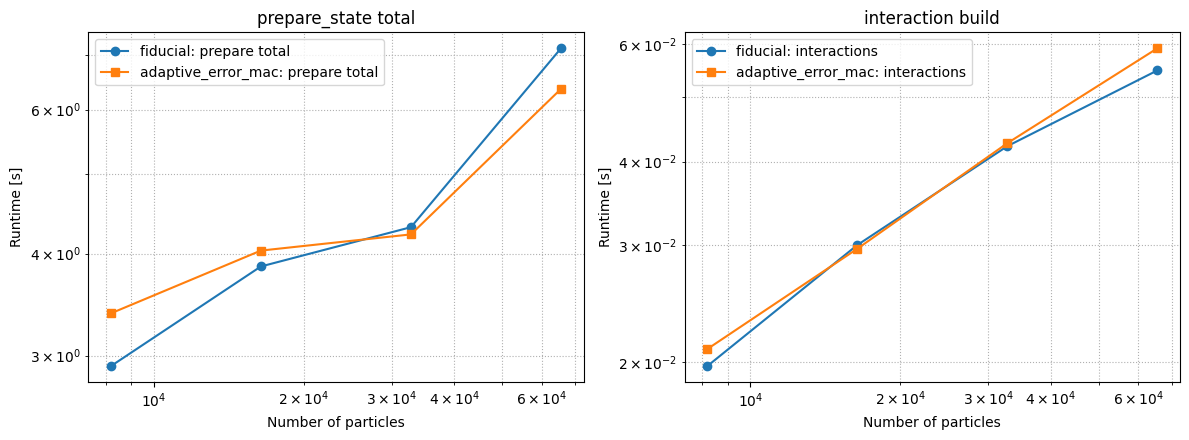

In [ ]:
fig, (ax_sum, ax_int) = plt.subplots(1, 2, figsize=(12, 4.5))
for setup_name, marker in [("fiducial", "o"), ("adaptive_error_mac", "s")]:
    cdf = runtime_component_results[setup_name]
    ax_sum.plot(
        cdf["num_particles"],
        cdf["prepare_component_sum_seconds"],
        marker=marker,
        label=f"{setup_name}: prepare total",
    )
    ax_int.plot(
        cdf["num_particles"],
        cdf["interactions_mean_seconds"],
        marker=marker,
        label=f"{setup_name}: interactions",
    )

for ax, title, ylabel in [
    (ax_sum, "prepare_state total", "Runtime [s]"),
    (ax_int, "interaction build", "Runtime [s]"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
runtime_index_precision = os.environ.get("JACCPOT_INDEX_PRECISION", "int64")

def _setup_traversal_cfg_value(setup_name, key):
    cfg = runtime_traversal_choices.get(str(setup_name)) if "runtime_traversal_choices" in globals() else None
    if not isinstance(cfg, dict):
        return np.nan
    val = cfg.get(str(key))
    return np.nan if val is None else int(val)

def _row_worker_traversal_cfg_value(worker_cfg, setup_name, key):
    if isinstance(worker_cfg, dict):
        val = worker_cfg.get(str(key))
        if val is not None:
            return int(val)
    return _setup_traversal_cfg_value(setup_name, key)

runtime_compare_df = runtime_compare_df.copy()
runtime_compare_df["index_precision"] = str(runtime_index_precision)
if "worker_traversal_config" not in runtime_compare_df.columns:
    runtime_compare_df["worker_traversal_config"] = None
if "worker_nearfield_edge_chunk_size" not in runtime_compare_df.columns:
    runtime_compare_df["worker_nearfield_edge_chunk_size"] = np.nan
if "benchmark_scope" not in runtime_compare_df.columns:
    runtime_compare_df["benchmark_scope"] = str(globals().get("runtime_benchmark_scope", "steady_eval"))

runtime_compare_df["traversal_tuned"] = runtime_compare_df.apply(
    lambda row: isinstance(row.get("worker_traversal_config"), dict)
    or isinstance((runtime_traversal_choices.get(str(row.get("setup"))) if "runtime_traversal_choices" in globals() else None), dict),
    axis=1,
)
for _key in [
    "max_pair_queue",
    "process_block",
    "max_interactions_per_node",
    "max_neighbors_per_leaf",
]:
    runtime_compare_df[f"traversal_{_key}"] = runtime_compare_df.apply(
        lambda row, k=_key: _row_worker_traversal_cfg_value(
            row.get("worker_traversal_config"),
            row.get("setup"),
            k,
        ),
        axis=1,
    )

runtime_compare_df["nearfield_edge_chunk_size"] = runtime_compare_df["worker_nearfield_edge_chunk_size"].map(
    lambda v: int(v) if pd.notna(v) else np.nan
)

runtime_config_summary_df = runtime_compare_df[
    [
        "setup",
        "num_particles",
        "index_precision",
        "traversal_tuned",
        "traversal_max_pair_queue",
        "traversal_process_block",
        "traversal_max_interactions_per_node",
        "traversal_max_neighbors_per_leaf",
        "nearfield_edge_chunk_size",
        "benchmark_scope",
        "worker_traversal_config",
        "worker_nearfield_edge_chunk_size",
        "mean_seconds",
        "prepare_mean_seconds",
        "evaluate_mean_seconds",
        "error",
    ]
].sort_values(["setup", "num_particles"])
runtime_config_summary_df

,setup,num_particles,index_precision,traversal_tuned,traversal_max_pair_queue,traversal_process_block,traversal_max_interactions_per_node,traversal_max_neighbors_per_leaf,nearfield_edge_chunk_size,benchmark_scope,worker_traversal_config,worker_nearfield_edge_chunk_size,mean_seconds,prepare_mean_seconds,evaluate_mean_seconds,error
12,adaptive_error_mac,8192,int32,True,262144.0,256.0,4096.0,1024.0,64.0,steady_eval,"{'max_pair_queue': 262144, 'process_block': 25...",64.0,0.034810,3.627629,0.034810,
13,adaptive_error_mac,16384,int32,True,524288.0,512.0,4096.0,1024.0,256.0,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",256.0,0.037596,4.652111,0.037596,
14,adaptive_error_mac,32768,int32,True,524288.0,512.0,4096.0,1024.0,256.0,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",256.0,0.086144,4.222247,0.086144,
15,adaptive_error_mac,65536,int32,True,524288.0,512.0,4096.0,1024.0,512.0,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",512.0,0.102961,6.525876,0.102961,
16,adaptive_error_mac,131072,int32,True,524288.0,512.0,4096.0,1024.0,512.0,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",512.0,0.170652,10.105242,0.170652,
17,adaptive_error_mac,262144,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
18,adaptive_error_mac,524288,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
19,adaptive_error_mac,1048576,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
20,adaptive_error_mac,2097152,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
21,adaptive_error_mac,4194304,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


## Apples-To-Apples Timing Breakdown

This section separates cold prepare, hot prepare, hot evaluate, and full acceleration calls to compare end-to-end vs steady-state kernel throughput.

In [ ]:
def _block_ready(value):
    return jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        value,
    )


apples_rows = []
apples_key = runtime_key
apples_setups = runtime_setups_tuned if "runtime_setups_tuned" in globals() else runtime_setups
for setup_name, fmm_kwargs in apples_setups.items():
    for n_particles in apples_particle_counts:
        positions, masses, apples_key = bench_utils.generate_random_distribution(
            int(n_particles),
            key=apples_key,
            dtype=runtime_working_dtype,
        )
        row = {
            "setup": setup_name,
            "num_particles": int(n_particles),
            "prepare_cold_seconds": np.nan,
            "prepare_hot_mean_seconds": np.nan,
            "evaluate_hot_mean_seconds": np.nan,
            "full_rebuild_mean_seconds": np.nan,
            "full_reuse_mean_seconds": np.nan,
            "eval_particles_per_sec": np.nan,
            "full_rebuild_particles_per_sec": np.nan,
            "error": "",
        }
        fmm = None
        try:
            fmm = FastMultipoleMethod(**fmm_kwargs)
            if runtime_autotune_cache_path.exists():
                fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)

            t0 = time.perf_counter()
            state_cold = fmm.prepare_state(
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
            )
            _ = _block_ready(state_cold)
            row["prepare_cold_seconds"] = float(time.perf_counter() - t0)

            prep_hot = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                warmup=apples_warmup,
                runs=apples_runs,
            )
            row["prepare_hot_mean_seconds"] = float(prep_hot.mean)

            eval_hot = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prep_hot.result,
                warmup=apples_warmup,
                runs=apples_runs,
                **_evaluate_prepared_kwargs(fmm),
            )
            row["evaluate_hot_mean_seconds"] = float(eval_hot.mean)

            full_rebuild = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                reuse_prepared_state=False,
                warmup=apples_warmup,
                runs=apples_runs,
            )
            row["full_rebuild_mean_seconds"] = float(full_rebuild.mean)

            full_reuse = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                reuse_prepared_state=True,
                warmup=apples_warmup,
                runs=apples_runs,
            )
            row["full_reuse_mean_seconds"] = float(full_reuse.mean)

            if np.isfinite(row["evaluate_hot_mean_seconds"]) and row["evaluate_hot_mean_seconds"] > 0:
                row["eval_particles_per_sec"] = float(
                    n_particles / row["evaluate_hot_mean_seconds"]
                )
            if np.isfinite(row["full_rebuild_mean_seconds"]) and row["full_rebuild_mean_seconds"] > 0:
                row["full_rebuild_particles_per_sec"] = float(
                    n_particles / row["full_rebuild_mean_seconds"]
                )
        except Exception as exc:
            row["error"] = f"{type(exc).__name__}: {exc}"
            print(f"[apples] setup={setup_name} N={n_particles} failed: {row['error']}")
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)
        apples_rows.append(row)

apples_df = pd.DataFrame(apples_rows).sort_values(["setup", "num_particles"])
apples_df

W0309 12:30:16.605759 3444304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1023.88MiB (rounded to 1073610752)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 12:30:16.606274 3444304 bfc_allocator.cc:513] *******************____****************************************________**********_____________****_*


[apples] setup=fiducial N=262144 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 1023.88MiB.


W0309 12:31:51.601353 3444304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 511.97MiB (rounded to 536838144)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 12:31:51.602228 3444304 bfc_allocator.cc:513] *******************______________*********************************************************____******


[apples] setup=fiducial N=524288 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 511.97MiB.


W0309 12:36:07.586873 3444304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 607.90MiB (rounded to 637433600)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 12:36:07.587414 3444304 bfc_allocator.cc:513] **********************_******************************________******____**********________*********_*


...

W0309 12:37:14.086359 3444304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 608.00MiB (rounded to 637539840)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 12:37:14.087076 3444304 bfc_allocator.cc:513] *****************************************************________********************________***********


[apples] setup=adaptive_error_mac N=262144 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 608.00MiB.


W0309 12:38:37.373640 3444304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 511.97MiB (rounded to 536838144)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 12:38:37.374026 3444304 bfc_allocator.cc:513] ****************************************************************************************************


[apples] setup=adaptive_error_mac N=524288 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 511.97MiB.


,setup,num_particles,prepare_cold_seconds,prepare_hot_mean_seconds,evaluate_hot_mean_seconds,full_rebuild_mean_seconds,full_reuse_mean_seconds,eval_particles_per_sec,full_rebuild_particles_per_sec,error
4,adaptive_error_mac,65536,84.091249,5.815030,0.117113,14.006507,0.361372,559594.601805,4678.967993,
5,adaptive_error_mac,131072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
6,adaptive_error_mac,262144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
7,adaptive_error_mac,524288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
0,fiducial,65536,119.805743,8.501532,0.198452,8.369146,1.212953,330235.195844,7830.667253,
1,fiducial,131072,170.089642,13.936192,0.459904,15.158092,1.450374,284998.615326,8646.998684,
2,fiducial,262144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
3,fiducial,524288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


In [ ]:
apples_summary_df = apples_df[
    [
        "setup",
        "num_particles",
        "prepare_cold_seconds",
        "prepare_hot_mean_seconds",
        "evaluate_hot_mean_seconds",
        "full_rebuild_mean_seconds",
        "full_reuse_mean_seconds",
        "eval_particles_per_sec",
        "full_rebuild_particles_per_sec",
        "error",
    ]
]
apples_summary_df

,setup,num_particles,prepare_cold_seconds,prepare_hot_mean_seconds,evaluate_hot_mean_seconds,full_rebuild_mean_seconds,full_reuse_mean_seconds,eval_particles_per_sec,full_rebuild_particles_per_sec,error
4,adaptive_error_mac,65536,84.091249,5.815030,0.117113,14.006507,0.361372,559594.601805,4678.967993,
5,adaptive_error_mac,131072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
6,adaptive_error_mac,262144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
7,adaptive_error_mac,524288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
0,fiducial,65536,119.805743,8.501532,0.198452,8.369146,1.212953,330235.195844,7830.667253,
1,fiducial,131072,170.089642,13.936192,0.459904,15.158092,1.450374,284998.615326,8646.998684,
2,fiducial,262144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
3,fiducial,524288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


## Accuracy Comparison (Vs Direct Sum)

Both setups are measured against a direct-sum reference. For large `N`, the reference is computed on a deterministic subset of targets to keep cost manageable.

In [ ]:
def _deterministic_sample_indices(n_items: int, cap: int | None) -> np.ndarray:
    if cap is None or cap <= 0 or n_items <= cap:
        return np.arange(n_items, dtype=np.int64)
    # Deterministic even-coverage sampling (no RNG variance in accuracy metrics).
    return np.linspace(0, n_items - 1, num=cap, dtype=np.int64)


def _direct_sum_accelerations_chunked(
    positions,
    masses,
    *,
    G: float,
    softening: float,
    target_indices,
    target_chunk: int,
    source_chunk: int,
):
    pos = np.asarray(positions)
    mass = np.asarray(masses)
    targets = np.asarray(target_indices, dtype=np.int64)
    out = np.zeros((targets.size, 3), dtype=pos.dtype)
    eps = np.finfo(pos.dtype).eps
    soft_sq = softening * softening

    for t0 in range(0, targets.size, target_chunk):
        t1 = min(t0 + target_chunk, targets.size)
        tidx = targets[t0:t1]
        p_t = pos[tidx]
        acc_t = np.zeros((tidx.size, 3), dtype=pos.dtype)

        for s0 in range(0, pos.shape[0], source_chunk):
            s1 = min(s0 + source_chunk, pos.shape[0])
            sidx = np.arange(s0, s1, dtype=np.int64)
            p_s = pos[s0:s1]
            m_s = mass[s0:s1]

            diff = p_t[:, None, :] - p_s[None, :, :]
            dist_sq = np.einsum("ijk,ijk->ij", diff, diff) + soft_sq
            dist = np.sqrt(dist_sq)
            inv_dist3 = 1.0 / (dist_sq * dist + eps)

            same = tidx[:, None] == sidx[None, :]
            inv_dist3[same] = 0.0

            weighted = m_s[None, :] * inv_dist3
            acc_t += -G * np.einsum("ij,ijk->ik", weighted, diff)

        out[t0:t1] = acc_t

    return out


accuracy_rows = []
acc_key = runtime_key
for n_particles in accuracy_particle_counts:
    positions, masses, acc_key = bench_utils.generate_random_distribution(
        int(n_particles),
        key=acc_key,
        dtype=runtime_working_dtype,
    )

    target_idx = _deterministic_sample_indices(int(n_particles), accuracy_direct_target_cap)
    acc_ref = _direct_sum_accelerations_chunked(
        positions,
        masses,
        G=1.0,
        softening=float(softening),
        target_indices=target_idx,
        target_chunk=int(accuracy_direct_target_chunk),
        source_chunk=int(accuracy_direct_source_chunk),
    )

    setup_fmms = {
        "fiducial": FastMultipoleMethod(**runtime_fmm_kwargs_fiducial),
        "adaptive_error_mac": FastMultipoleMethod(**runtime_fmm_kwargs_adaptive),
    }
    for setup_name, fmm in setup_fmms.items():
        if runtime_autotune_cache_path.exists():
            try:
                fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)
            except Exception as exc:
                print(f"[accuracy:{setup_name}] autotune cache load failed for N={n_particles}: {type(exc).__name__}: {exc}")

        acc_est = fmm.compute_accelerations(
            positions,
            masses,
            leaf_size=runtime_leaf_size,
            max_order=runtime_max_order,
            reuse_prepared_state=False,
        )
        acc_est_subset = np.asarray(acc_est)[target_idx]
        diff = acc_est_subset - acc_ref
        ref_norm = np.linalg.norm(acc_ref)
        rel_l2 = float(np.linalg.norm(diff) / max(ref_norm, 1e-12))
        denom = np.linalg.norm(acc_ref, axis=1)
        err = np.linalg.norm(diff, axis=1)
        rel_max = float(np.max(err / np.maximum(denom, 1e-12)))
        max_abs = float(np.max(np.abs(diff)))

        accuracy_rows.append(
            {
                "setup": setup_name,
                "num_particles": int(n_particles),
                "num_reference_targets": int(target_idx.size),
                "relative_l2": rel_l2,
                "relative_max": rel_max,
                "max_abs": max_abs,
            }
        )

        fmm.clear_runtime_caches(clear_jax_compilation=True)

accuracy_df = pd.DataFrame(accuracy_rows).sort_values(["setup", "num_particles"])
accuracy_df

W0309 12:45:33.832086 3444304 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 40.01MiB (rounded to 41953024)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0309 12:45:33.832764 3444304 bfc_allocator.cc:513] ****************************************************************************************************


JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 40.01MiB.

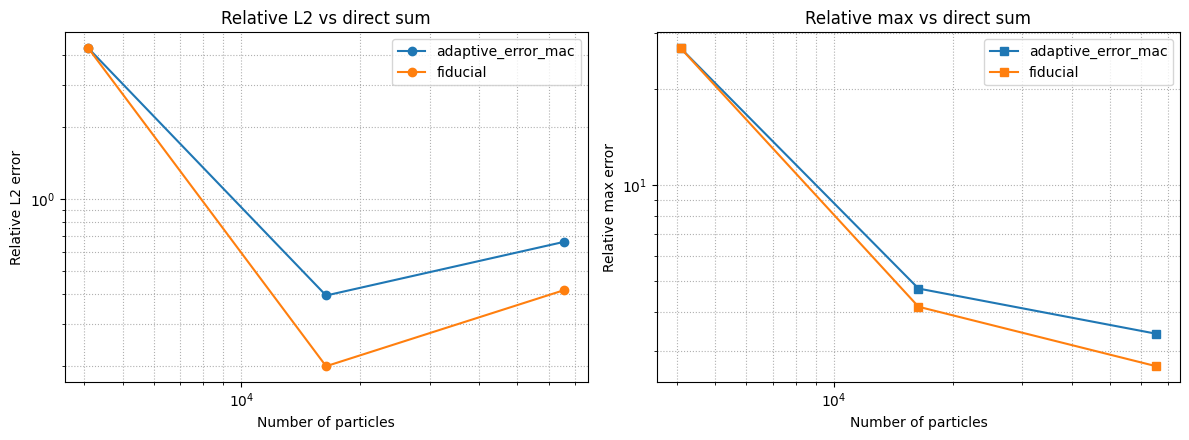

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for setup_name, sdf in accuracy_df.groupby("setup"):
    axes[0].plot(sdf["num_particles"], sdf["relative_l2"], "o-", label=setup_name)
    axes[1].plot(sdf["num_particles"], sdf["relative_max"], "s-", label=setup_name)

for ax, title, ylabel in [
    (axes[0], "Relative L2 vs direct sum", "Relative L2 error"),
    (axes[1], "Relative max vs direct sum", "Relative max error"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

## Notes

- This notebook is GPU-focused and will fail early if no GPU is visible to JAX.
- `JACCPOT_INDEX_PRECISION` / `YGGDRAX_INDEX_PRECISION` is set at notebook start (`INDEX_PRECISION`) to switch index width (`int32`/`int64`). Restart kernel after changes.
- `runtime_autotune_cache_path` persists M2L chunk tuning across worker processes and future runs.
- `runtime_traversal_autotune_cache_path` persists traversal-capacity tuning (queue/block/neighbor/interaction caps) chosen from `runtime_traversal_candidates`.
- `runtime_runtime_autotune_cache_path` persists worker-selected runtime tuning (`worker_traversal_config`, `worker_nearfield_edge_chunk_size`) keyed by GPU/runtime signature.
- `runtime_benchmark_scope` defaults to `steady_eval` (hot prepared-state evaluation). Set to `full` for end-to-end rebuild timing.
- Runtime benchmarking compares two setups:
  - `fiducial` (`large_n_gpu` preset)
  - `adaptive_error_mac` (adaptive expansion order + error-controlled MAC)
- `runtime_worker_autotune_traversal` / `runtime_worker_autotune_nearfield_chunk` enable worker-side tuning (enabled by default in this notebook).
- Accuracy is measured against a chunked direct-sum reference. For large `N`, a deterministic target subset is used (`accuracy_direct_target_cap`).
- Run the notebook from the first cell so GPU/XLA environment flags are applied before JAX initializes.